In [ ]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans
import numpy as np

print('Good imports!')

Good imports!


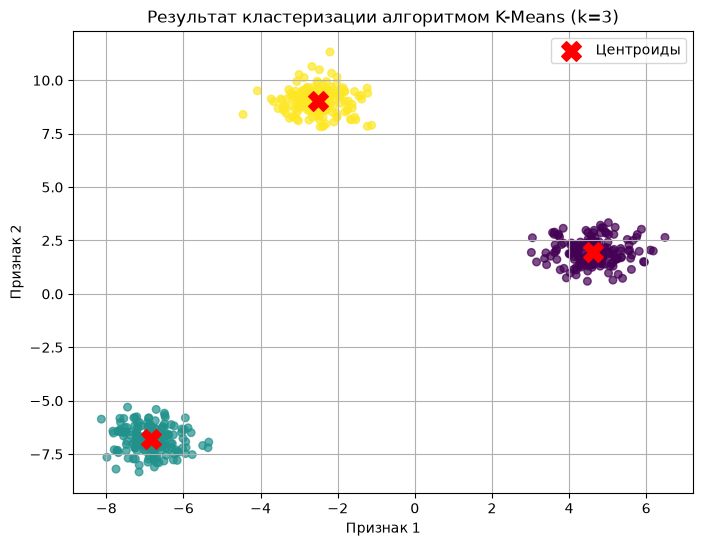

In [2]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.6, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X)

y_kmeans = kmeans.predict(X)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=30, cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Центроиды')

plt.title("Результат кластеризации алгоритмом K-Means (k=3)")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.legend()
plt.grid(True)
plt.show()

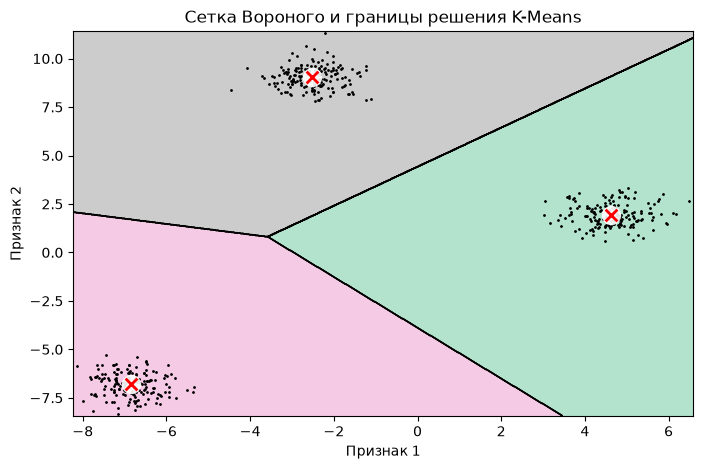

In [3]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='r'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), colors='k', linewidths=1)
    plot_data(X)
    plot_centroids(clusterer.cluster_centers_)

plt.figure(figsize=(8, 5))
plot_decision_boundaries(kmeans, X)
plt.title("Сетка Вороного и границы решения K-Means")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.show()


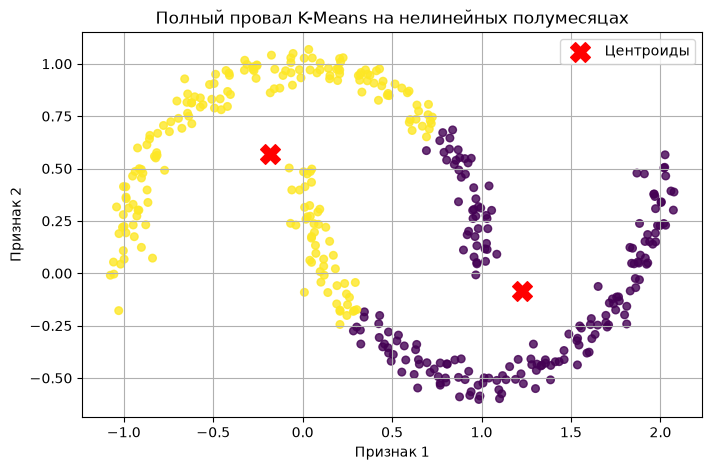

In [5]:
from sklearn.datasets import make_moons

X_moons, _ = make_moons(n_samples=400, noise=0.05, random_state=42)
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_moons.fit(X_moons)
y_pred_moons = kmeans_moons.predict(X_moons)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_pred_moons, s=30, cmap='viridis', alpha=0.8)
plt.scatter(kmeans_moons.cluster_centers_[:, 0], kmeans_moons.cluster_centers_[:, 1], 
            c='red', s=200, marker='X', label='Центроиды')

plt.title("Полный провал K-Means на нелинейных полумесяцах")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.legend()
plt.grid(True)
plt.show()
